In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Loan_Default.csv")

In [ ]:
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38403,63293,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CRIF,534.0,CIB,45-54,to_inst,79.454023,south,direct,0.0,42.0
38404,63294,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,EXP,719.0,EXP,55-64,not_inst,47.271825,North,direct,0.0,48.0
38405,63295,2019,cf,Joint,nopre,type1,p4,l1,nopc,nob/c,...,CRIF,746.0,EXP,45-54,not_inst,54.105839,North,direct,0.0,21.0
38406,63296,2019,ncf,Joint,nopre,type1,p4,l1,nopc,nob/c,...,EQUI,727.0,EXP,65-74,to_inst,NaN,North,direct,1.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38408 entries, 0 to 38407
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         38408 non-null  int64  
 1   year                       38408 non-null  int64  
 2   loan_limit                 37554 non-null  object 
 3   Gender                     38408 non-null  object 
 4   approv_in_adv              38182 non-null  object 
 5   loan_type                  38408 non-null  object 
 6   loan_purpose               38383 non-null  object 
 7   Credit_Worthiness          38408 non-null  object 
 8   open_credit                38408 non-null  object 
 9   business_or_commercial     38408 non-null  object 
 10  loan_amount                38408 non-null  int64  
 11  rate_of_interest           29052 non-null  float64
 12  Interest_rate_spread       28999 non-null  float64
 13  Upfront_charges            28253 non-null  flo

In [ ]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,38408.000000,38408.0,3.840800e+04,29052.000000,28999.000000,28253.000000,38396.000000,3.448000e+04,36124.000000,38407.000000,34480.000000,38407.000000,32231.000000
mean,44093.500000,2019.0,3.319023e+05,4.046412,0.439522,3254.015246,335.304615,4.976932e+05,6934.653970,700.293176,72.867344,0.244981,37.855915
std,11087.578906,0.0,1.833525e+05,0.557681,0.511506,3275.464592,58.079424,3.621892e+05,6435.427155,115.811213,45.785385,0.430082,10.480902
min,24890.000000,2019.0,2.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,2.813745,0.000000,5.000000
25%,34491.750000,2019.0,1.965000e+05,3.625000,0.076050,594.600000,360.000000,2.680000e+05,3720.000000,600.000000,60.658915,0.000000,31.000000
50%,44093.500000,2019.0,2.965000e+05,3.990000,0.387300,2603.950000,360.000000,4.180000e+05,5760.000000,700.000000,75.152439,0.000000,39.000000
75%,53695.250000,2019.0,4.365000e+05,4.375000,0.765050,4870.000000,360.000000,6.205000e+05,8460.000000,801.000000,86.005435,0.000000,45.000000
max,63297.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,377220.000000,900.000000,7831.250000,1.000000,61.000000


In [ ]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,854
Gender,0
approv_in_adv,226
loan_type,0
loan_purpose,25
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


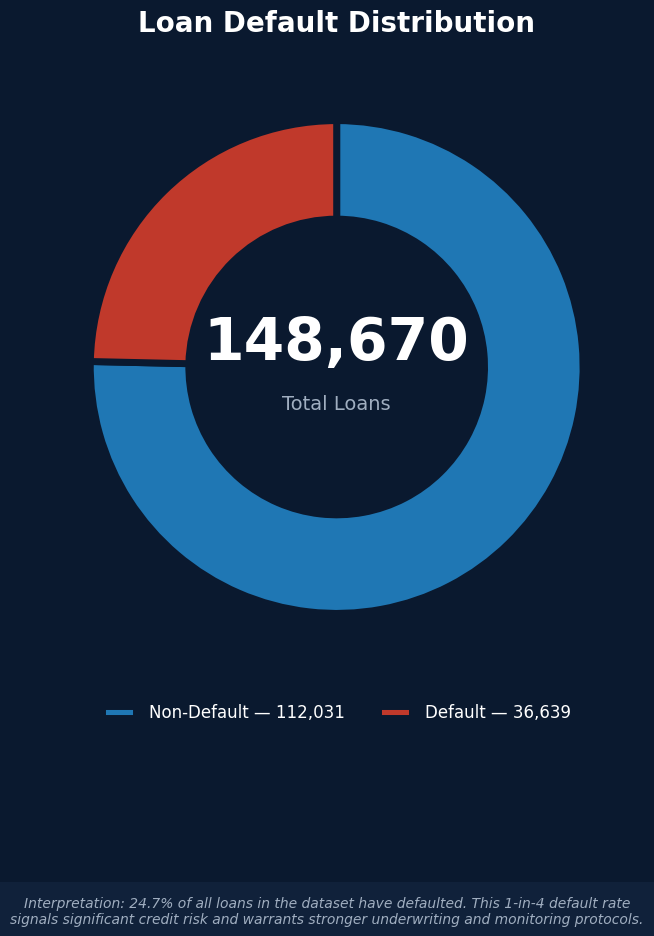

In [ ]:
# Data from your image
labels = ['Non-Default', 'Default']
counts = [112031, 36639]
colors = ['#1f77b4', '#c0392b']  # Blue and Red/Orange shades
total_loans = sum(counts)

# Set the dark background style
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#0a192f')
ax.set_facecolor('#0a192f')

# Create the pie chart
# 'wedgeprops' with width creates the donut hole effect
wedges, texts = ax.pie(
    counts,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={'width': 0.4, 'edgecolor': '#0a192f', 'linewidth': 5}
)

# Add the center text
ax.text(0, 0.1, f'{total_loans:,}', ha='center', va='center',
        fontsize=42, fontweight='bold', color='white')
ax.text(0, -0.15, 'Total Loans', ha='center', va='center',
        fontsize=14, color='#a0aec0')

# Add the Title
plt.title('Loan Default Distribution', fontsize=20, fontweight='bold', pad=20)

# Add the custom Legend at the bottom
legend_labels = [f"{labels[i]} — {counts[i]:,}" for i in range(len(labels))]
plt.legend(
    wedges, legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False,
    fontsize=12
)

# Interpretation text box at the bottom
interpretation = ("Interpretation: 24.7% of all loans in the dataset have defaulted. "
                  "This 1-in-4 default rate\nsignals significant credit risk and "
                  "warrants stronger underwriting and monitoring protocols.")

plt.figtext(0.5, -0.2, interpretation, ha="center", fontsize=10,
            style='italic', color='#a0aec0',
            bbox={'facecolor': '#172a45', 'alpha': 0.5, 'pad': 10, 'edgecolor': 'none'})

plt.show()

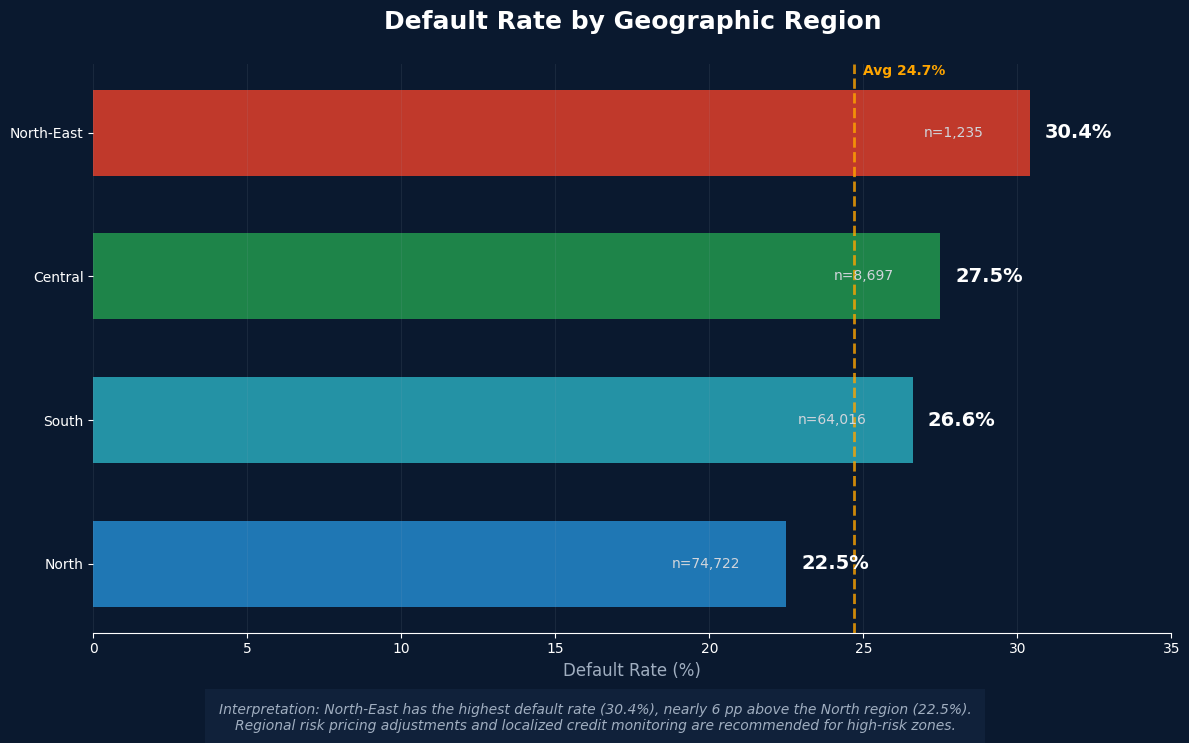

In [ ]:
# Data from the image
regions = ['North-East', 'Central', 'South', 'North']
default_rates = [30.4, 27.5, 26.6, 22.5]
sample_sizes = [1235, 8697, 64016, 74722]
avg_rate = 24.7

# Specific colors used in the chart
colors = ['#c0392b', '#1e8449', '#2492a5', '#1f77b4']

# Setup the dark style
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0a192f')
ax.set_facecolor('#0a192f')

# Create horizontal bars
bars = ax.barh(regions, default_rates, color=colors, height=0.6)

# Invert y-axis to match the image (North-East on top)
ax.invert_yaxis()

# Add a vertical dashed line for the average
ax.axvline(x=avg_rate, color='orange', linestyle='--', linewidth=2, alpha=0.8)
ax.text(avg_rate + 0.3, -0.4, f'Avg {avg_rate}%', color='orange', fontweight='bold')

# Add text labels (Percentages and Sample Sizes)
for i, bar in enumerate(bars):
    width = bar.get_width()

    # Large percentage label at the end of the bar
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}%',
            va='center', fontweight='bold', fontsize=14)

    # Sample size (n) inside the bar
    ax.text(width - 1.5, bar.get_y() + bar.get_height()/2, f'n={sample_sizes[i]:,}',
            va='center', ha='right', color='#d1d5db', fontsize=10)

# Styling axes and grid
ax.set_xlabel('Default Rate (%)', fontsize=12, color='#a0aec0')
ax.set_xlim(0, 35)
ax.grid(axis='x', linestyle='-', alpha=0.1, color='#a0aec0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Title and Interpretation Box
plt.title('Default Rate by Geographic Region', fontsize=18, fontweight='bold', pad=25)

interpretation = ("Interpretation: North-East has the highest default rate (30.4%), nearly 6 pp above the North region (22.5%).\n"
                  "Regional risk pricing adjustments and localized credit monitoring are recommended for high-risk zones.")

plt.figtext(0.5, -0.05, interpretation, ha="center", fontsize=10,
            style='italic', color='#a0aec0',
            bbox={'facecolor': '#172a45', 'alpha': 0.5, 'pad': 10, 'edgecolor': 'none'})

plt.tight_layout()
plt.show()

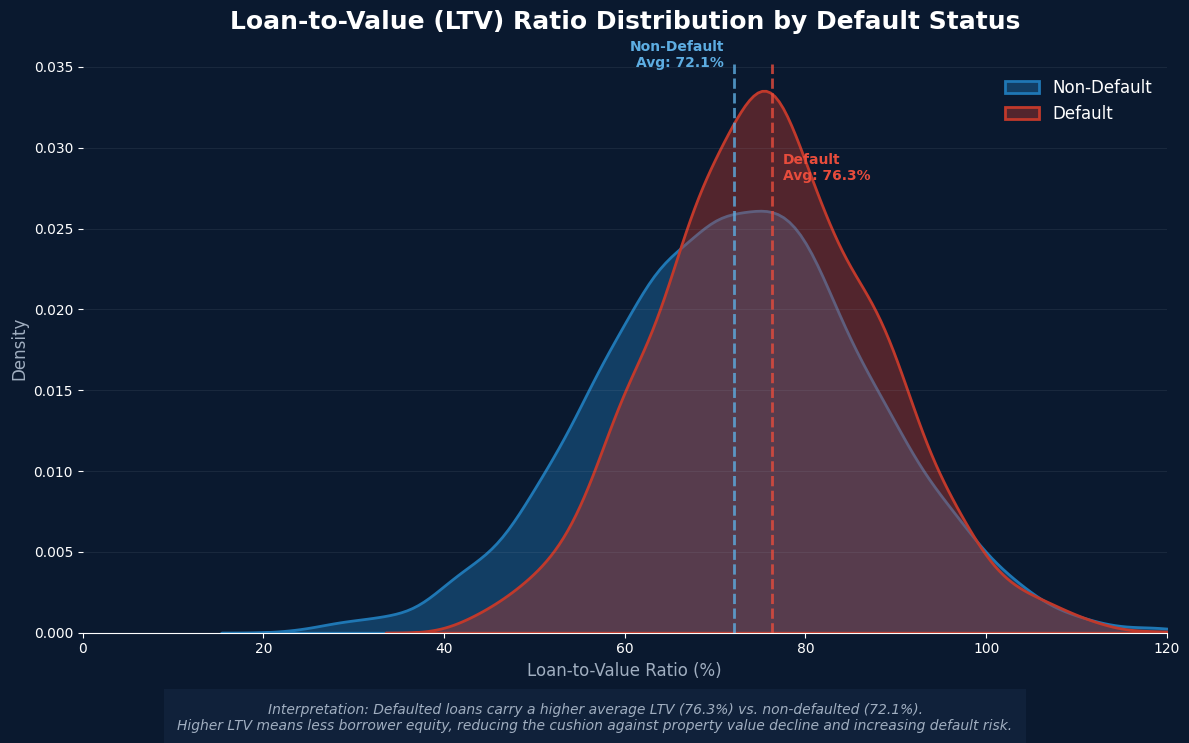

In [ ]:
# Set the dark theme background
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0a192f')
ax.set_facecolor('#0a192f')

# Mock data generation (to match the distribution shapes in the images)
np.random.seed(42)
non_default_ltv = np.random.normal(loc=72.1, scale=15, size=5000)
default_ltv = np.random.normal(loc=76.3, scale=12, size=2000)

# Colors from the image
blue_color = '#1f77b4'
red_color = '#c0392b'

# Plot KDE (Density) for both groups
sns.kdeplot(non_default_ltv, fill=True, color=blue_color, alpha=0.4, label='Non-Default', linewidth=2, ax=ax)
sns.kdeplot(default_ltv, fill=True, color=red_color, alpha=0.4, label='Default', linewidth=2, ax=ax)

# Add Vertical Average Lines
ax.axvline(x=72.1, color='#5dade2', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(x=76.3, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)

# Add text labels for the averages
ax.text(71, 0.035, 'Non-Default\nAvg: 72.1%', color='#5dade2', fontweight='bold', ha='right', fontsize=10)
ax.text(77.5, 0.028, 'Default\nAvg: 76.3%', color='#e74c3c', fontweight='bold', ha='left', fontsize=10)

# Styling axes and labels
ax.set_title('Loan-to-Value (LTV) Ratio Distribution by Default Status', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Loan-to-Value Ratio (%)', fontsize=12, color='#a0aec0')
ax.set_ylabel('Density', fontsize=12, color='#a0aec0')
ax.set_xlim(0, 120)
ax.grid(axis='y', linestyle='-', alpha=0.1, color='#a0aec0')

# Clean up spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Legend setup
plt.legend(frameon=False, fontsize=12, loc='upper right')

# Add Interpretation text box at the bottom
interpretation = ("Interpretation: Defaulted loans carry a higher average LTV (76.3%) vs. non-defaulted (72.1%).\n"
                  "Higher LTV means less borrower equity, reducing the cushion against property value decline and increasing default risk.")

plt.figtext(0.5, -0.05, interpretation, ha="center", fontsize=10,
            style='italic', color='#a0aec0',
            bbox={'facecolor': '#172a45', 'alpha': 0.5, 'pad': 10, 'edgecolor': 'none'})

plt.tight_layout()
plt.show()

/tmp/ipykernel_8193/3482069176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Credit_Score', data=df, palette='coolwarm')


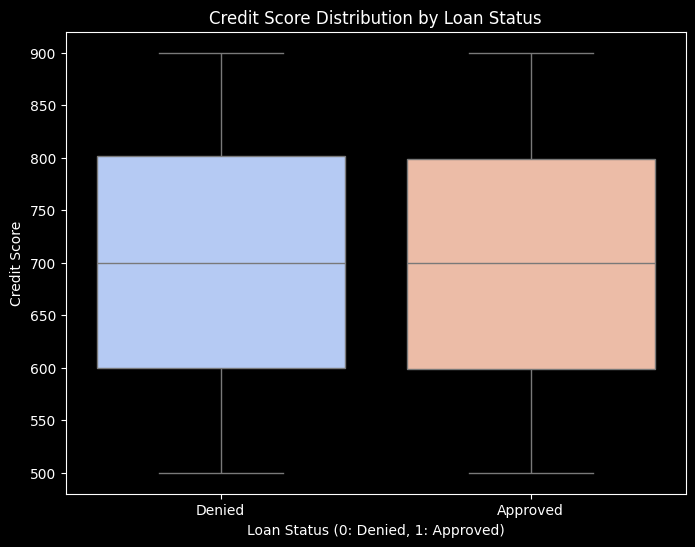

Insight 4: Approved loans (Status = 1) show a noticeably higher median credit score and a tighter distribution with fewer outliers on the lower end compared to denied loans (Status = 0). This suggests credit score is a strong predictor for loan approval.


In [ ]:
# 4. Box Plot: Credit Score by Loan Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Status', y='Credit_Score', data=df, palette='coolwarm')
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Loan Status (0: Denied, 1: Approved)')
plt.ylabel('Credit Score')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Approved'])
plt.show()
print("Insight 4: Approved loans (Status = 1) show a noticeably higher median credit score and a tighter distribution with fewer outliers on the lower end compared to denied loans (Status = 0). This suggests credit score is a strong predictor for loan approval.")


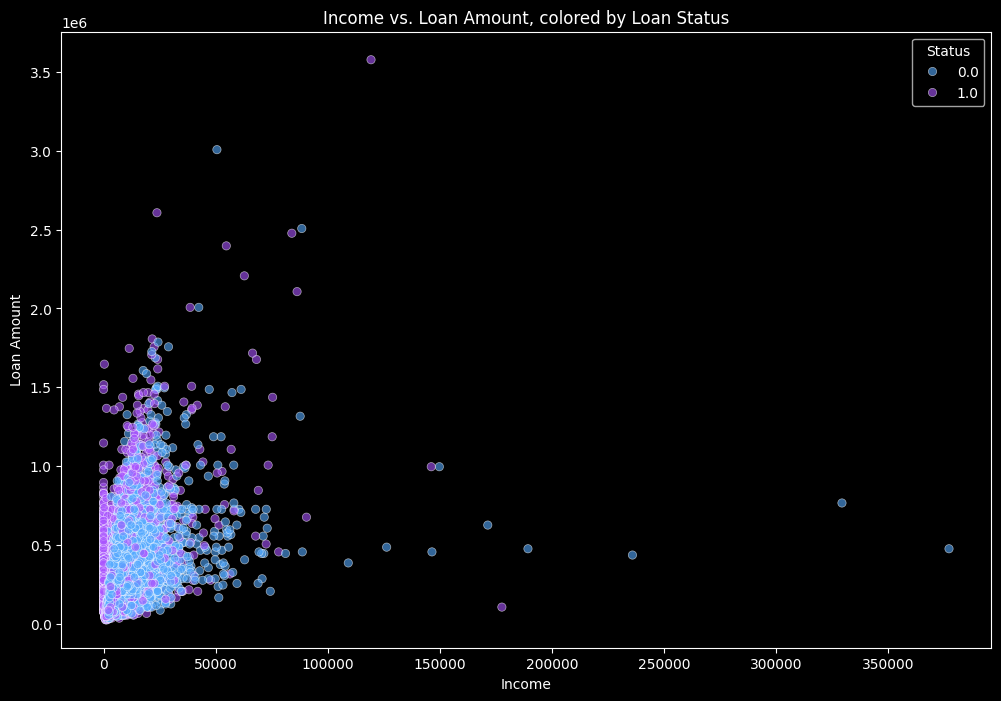

Insight 5: The scatter plot indicates a positive correlation between income and loan amount. Approved loans tend to be concentrated among higher-income individuals for various loan amounts, while denied loans are more dispersed, especially at lower income levels.


In [ ]:
# 5. Scatter Plot: Income vs. Loan Amount, colored by Status
plt.figure(figsize=(12, 8))
sns.scatterplot(x='income', y='loan_amount', hue='Status', data=df, palette='cool', alpha=0.6)
plt.title('Income vs. Loan Amount, colored by Loan Status')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()
print("Insight 5: The scatter plot indicates a positive correlation between income and loan amount. Approved loans tend to be concentrated among higher-income individuals for various loan amounts, while denied loans are more dispersed, especially at lower income levels.")


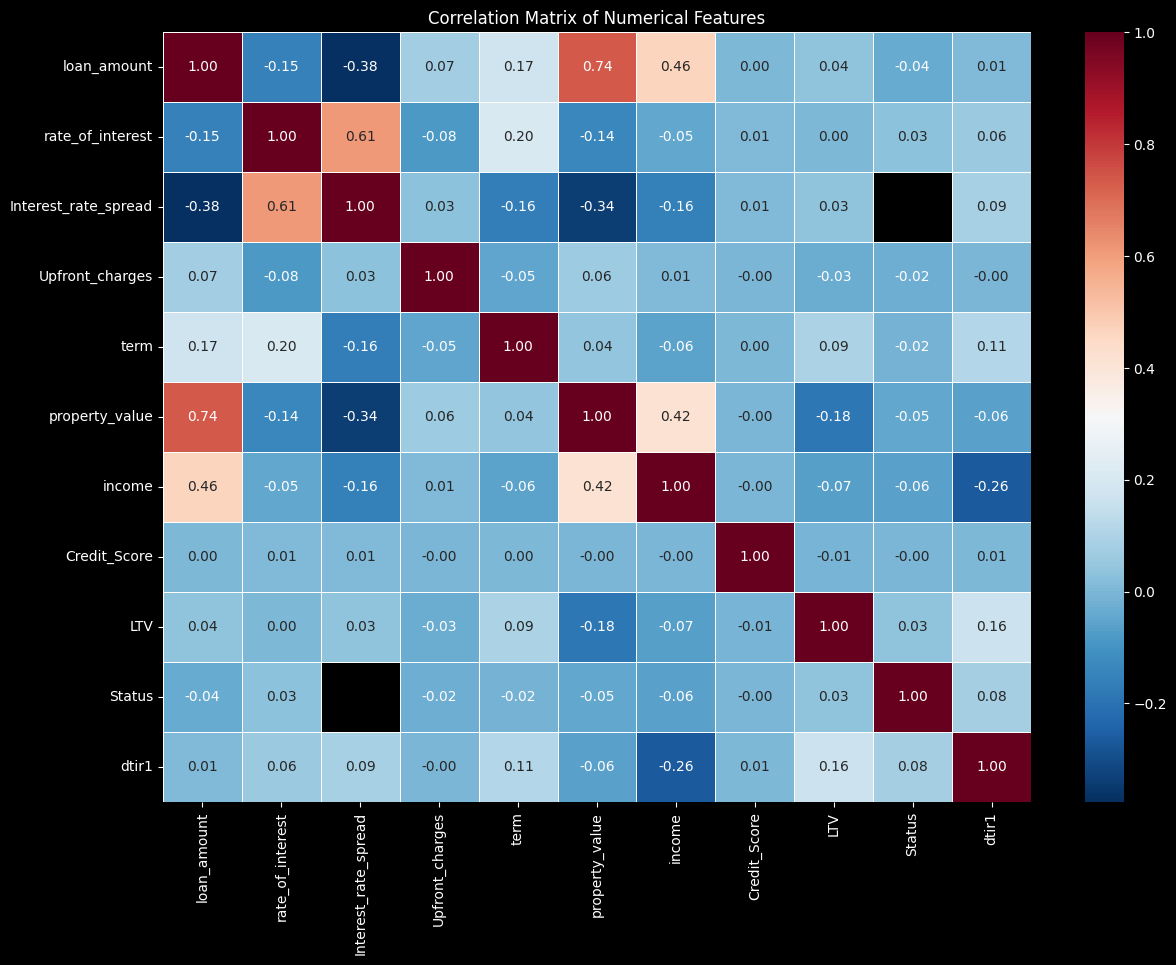

Insight 6: The heatmap illustrates the linear relationships between numerical variables. Strong positive correlations might exist between 'loan_amount' and 'property_value', and a notable correlation can be observed between 'Credit_Score' and 'Status', suggesting their influence on each other.


In [ ]:
# 6. Heatmap: Correlation Matrix of Numerical Features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'ID' and 'year' if they are not meaningful for correlation or are constant
if 'ID' in numerical_cols: numerical_cols.remove('ID')
if 'year' in numerical_cols: numerical_cols.remove('year') # year is constant 2019

# Calculate correlation matrix, handling potential NaNs by dropping for correlation calculation
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Insight 6: The heatmap illustrates the linear relationships between numerical variables. Strong positive correlations might exist between 'loan_amount' and 'property_value', and a notable correlation can be observed between 'Credit_Score' and 'Status', suggesting their influence on each other.")


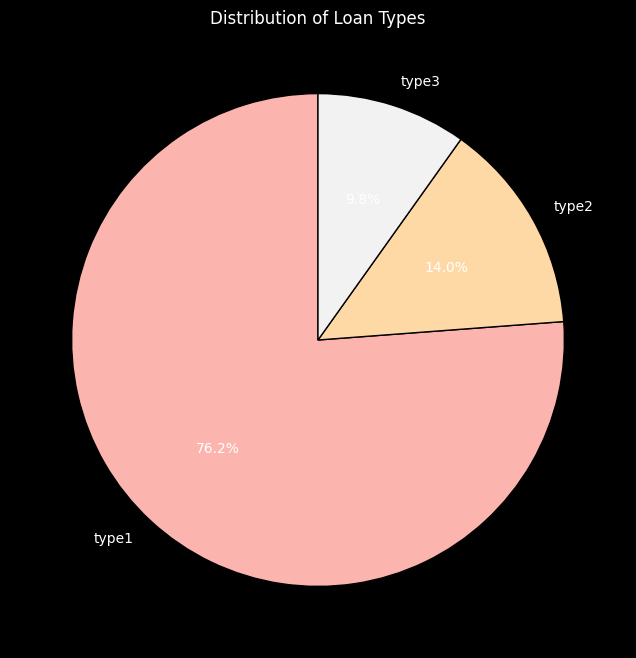

Insight 7: 'type1' loans dominate the dataset, accounting for the largest proportion of loan applications. This highlights the popularity or prevalence of this specific loan product compared to others.


In [ ]:
# 7. Pie Chart: Distribution of Loan Types
# Ensure 'loan_type' column does not have too many unique values for a readable pie chart
plt.figure(figsize=(8, 8))
df['loan_type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Loan Types')
plt.ylabel('') # Hide the default 'loan_type' label for pie chart
plt.show()
print("Insight 7: 'type1' loans dominate the dataset, accounting for the largest proportion of loan applications. This highlights the popularity or prevalence of this specific loan product compared to others.")


/tmp/ipykernel_8193/3779951021.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loan_by_age = df.dropna(subset=['age']).groupby('age')['loan_amount'].mean().reset_index()


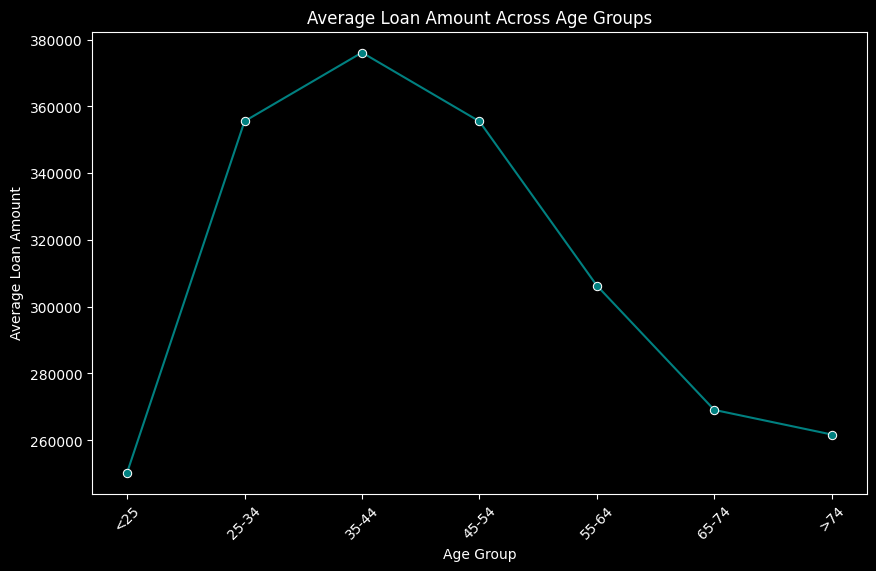

Insight 8: The line plot reveals a trend in average loan amounts across age groups, often peaking in mid-career age groups (e.g., 35-54) and potentially declining in older demographics. This could reflect varying financial needs and stability over a person's life.


In [ ]:
# 8. Line Plot: Average Loan Amount across Age Groups
# Define the correct order for age groups if they are categorical strings
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']
# Convert 'age' column to a categorical type with the specified order
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True)

# Calculate the average loan amount for each age group, dropping NaNs in 'age' first
avg_loan_by_age = df.dropna(subset=['age']).groupby('age')['loan_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='loan_amount', data=avg_loan_by_age, marker='o', color='teal')
plt.title('Average Loan Amount Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Average Loan Amount')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.show()
print("Insight 8: The line plot reveals a trend in average loan amounts across age groups, often peaking in mid-career age groups (e.g., 35-54) and potentially declining in older demographics. This could reflect varying financial needs and stability over a person's life.")


/tmp/ipykernel_8193/1756525805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y='rate_of_interest', data=df.dropna(subset=['rate_of_interest']), palette='magma')


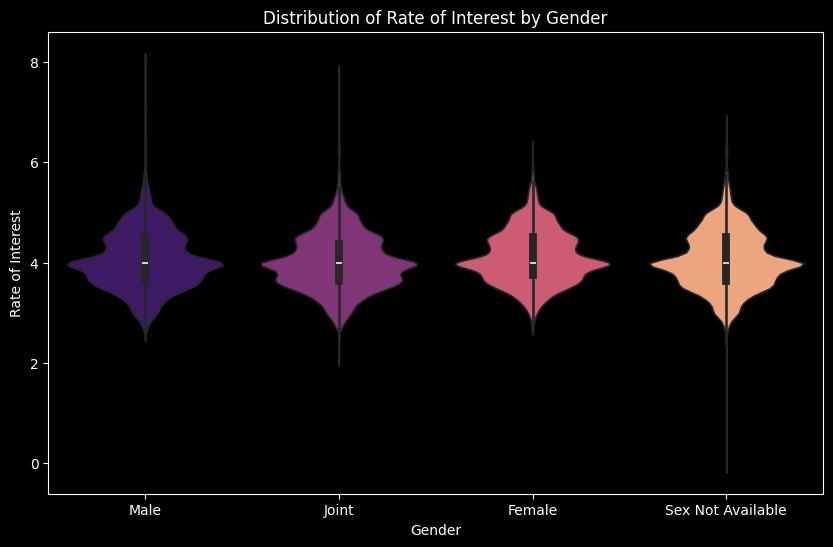

Insight 9: The violin plot shows the distribution of interest rates for different genders. While median rates might be similar, the plot can highlight differences in the spread or density of rates, indicating specific rate tiers more commonly assigned to certain gender categories.


In [ ]:
# 9. Violin Plot: Rate of Interest by Gender
# Drop rows with NaN in 'rate_of_interest' for accurate plotting
plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='rate_of_interest', data=df.dropna(subset=['rate_of_interest']), palette='magma')
plt.title('Distribution of Rate of Interest by Gender')
plt.xlabel('Gender')
plt.ylabel('Rate of Interest')
plt.show()
print("Insight 9: The violin plot shows the distribution of interest rates for different genders. While median rates might be similar, the plot can highlight differences in the spread or density of rates, indicating specific rate tiers more commonly assigned to certain gender categories.")


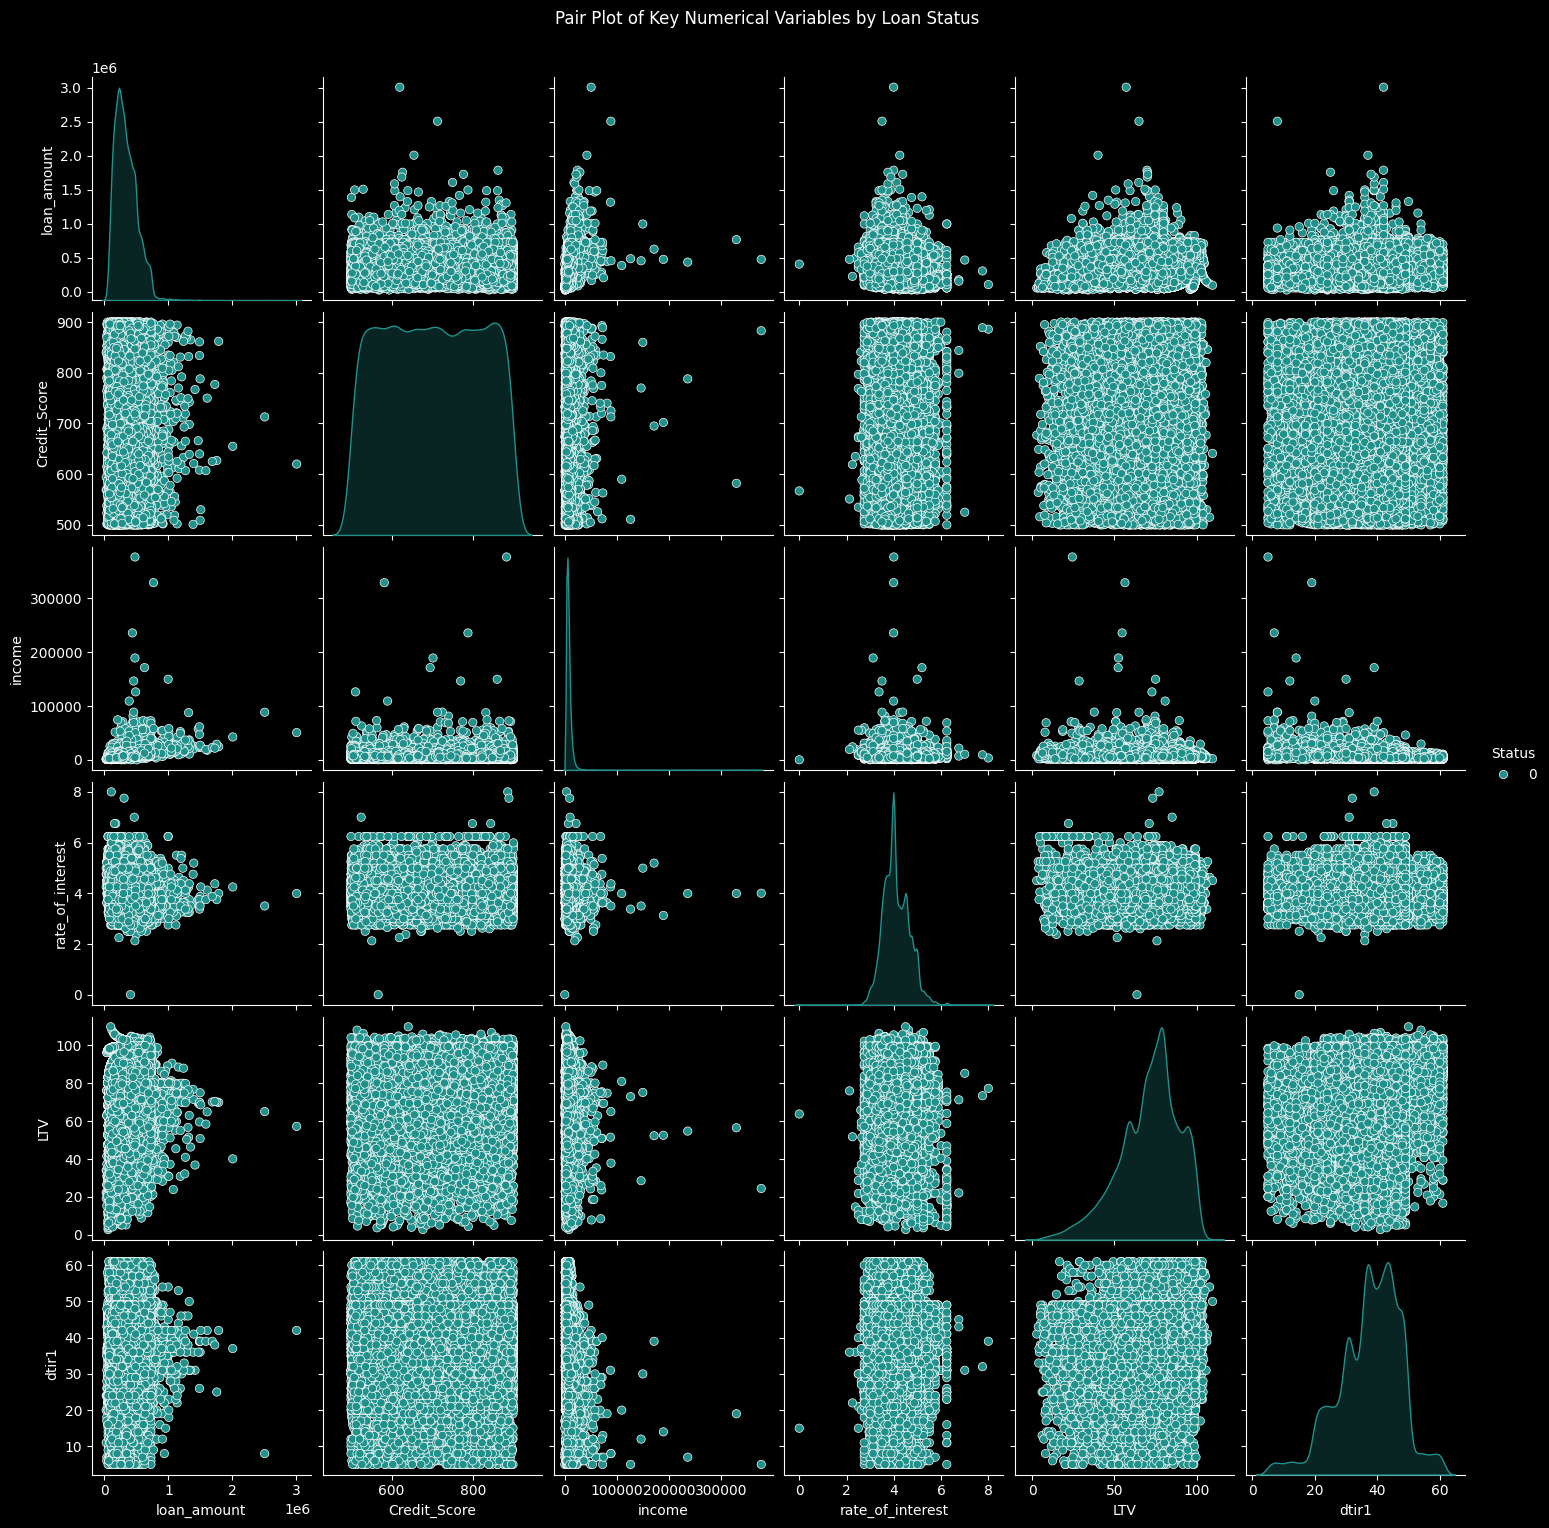

Insight 10: The pair plot offers a comprehensive view of relationships among key numerical variables, differentiated by loan status. It can reveal patterns like how 'Credit_Score' strongly separates approved from denied loans, or how distributions of 'income' and 'loan_amount' vary for each status, providing a holistic understanding of the data.


In [ ]:
# 10. Pair Plot: Relationships between key numerical variables
# Select a subset of relevant numerical columns for clarity in pair plot
selected_numerical_cols = ['loan_amount', 'Credit_Score', 'income', 'rate_of_interest', 'LTV', 'dtir1', 'Status']

# Create a copy and drop rows with NaN in these selected columns for clean plotting
pair_df = df[selected_numerical_cols].dropna().copy()

# Convert 'Status' to categorical for better hue representation in the pair plot
pair_df['Status'] = pair_df['Status'].astype(int).astype('category')

sns.pairplot(pair_df, hue='Status', diag_kind='kde', palette='viridis')
plt.suptitle('Pair Plot of Key Numerical Variables by Loan Status', y=1.02) # Adjust suptitle position
plt.show()
print("Insight 10: The pair plot offers a comprehensive view of relationships among key numerical variables, differentiated by loan status. It can reveal patterns like how 'Credit_Score' strongly separates approved from denied loans, or how distributions of 'income' and 'loan_amount' vary for each status, providing a holistic understanding of the data.")
